In [1]:
%load_ext autoreload
%autoreload 2
import helper_functions as hf
from imports import *
import importlib

num_available_cpus = multiprocessing.cpu_count()
print("Number of available CPUs:", num_available_cpus)

torch.cuda.empty_cache()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device =", device)
torch.set_default_tensor_type('torch.cuda.FloatTensor') if torch.cuda.is_available() else print ('cpu')

torch.set_num_threads(num_available_cpus)

print("Number of threads:", torch.get_num_threads())
print("Number of interop threads:", torch.get_num_interop_threads())

/nobackup/users/sambt/anaconda3/envs/quak/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Number of available CPUs: 80
Device = cuda:0
Number of threads: 80
Number of interop threads: 80


# Load QCD background

In [2]:
year = 2017
train,unnorm,mass,names = hf.LAPS_train("QCDBKG",year,num_batches=-1,Mjj_cut=800,pt_cut=300)
mass = mass.flatten()

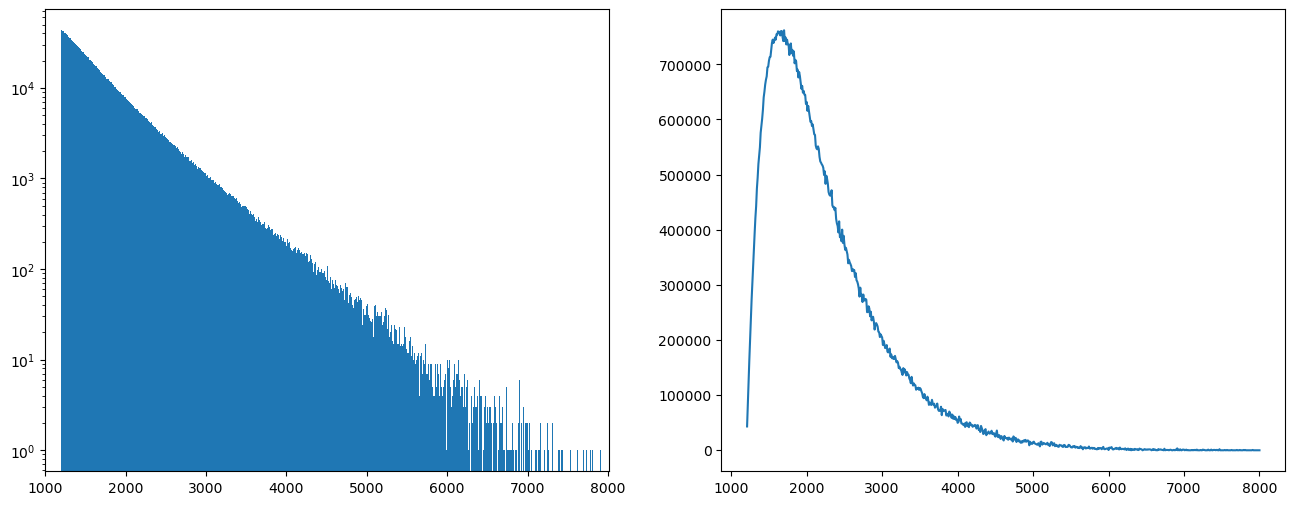

In [3]:
plt.figure(figsize=(16,6))
step = 10
bins = bins=np.arange(1200,8000+step,step)
plt.subplot(121)
counts,bins,patch = plt.hist(mass,bins=bins)
plt.xlim([1000,8000+step])
plt.yscale('log')

upperLims = bins[1:]
possibleWithUniform = []
for i,ct in enumerate(counts):
    nbins = i+1
    ntot = nbins*ct
    possibleWithUniform.append(ntot)
possibleWithUniform = np.array(possibleWithUniform)
plt.subplot(122)
plt.plot(upperLims,possibleWithUniform)

mMax = upperLims[np.max(np.where((possibleWithUniform-100000)>0)[0])]

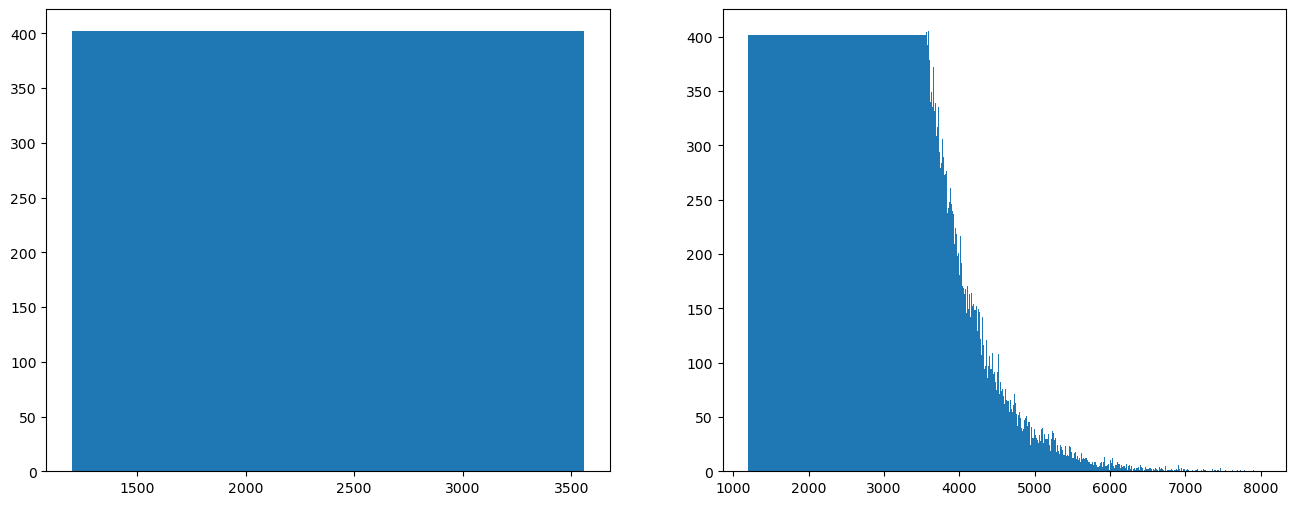

In [4]:
itail = (mass >= mMax).nonzero()
tail = train[itail]
mtail = mass[itail]

ibulk = (mass < mMax).nonzero()
bulk = train[ibulk]
mbulk = mass[ibulk]

# sample uniformly from bulk
bins = np.arange(1200,mMax+step,step)
nBins = len(bins)-1
bulkBins = np.digitize(mbulk,bins)
nToSample = np.min([len(bulkBins[bulkBins==i]) for i in range(1,nBins+1)])
sampleInds = [(bulkBins==i).nonzero()[0][:nToSample] for i in range(1,nBins+1)]
sample = np.concatenate([bulk[inds] for inds in sampleInds],axis=0)
mSample = np.concatenate([mbulk[inds] for inds in sampleInds],axis=0)

plt.figure(figsize=(16,6))
plt.subplot(121)
h = plt.hist(mSample,bins)

totalSample = np.concatenate((sample,tail),axis=0)
totalMass = np.concatenate((mSample,mtail),axis=0)
plt.subplot(122)
h = plt.hist(totalMass,bins=np.arange(1200,8000+step,step))

# Compare mass-flattened inputs to inclusive

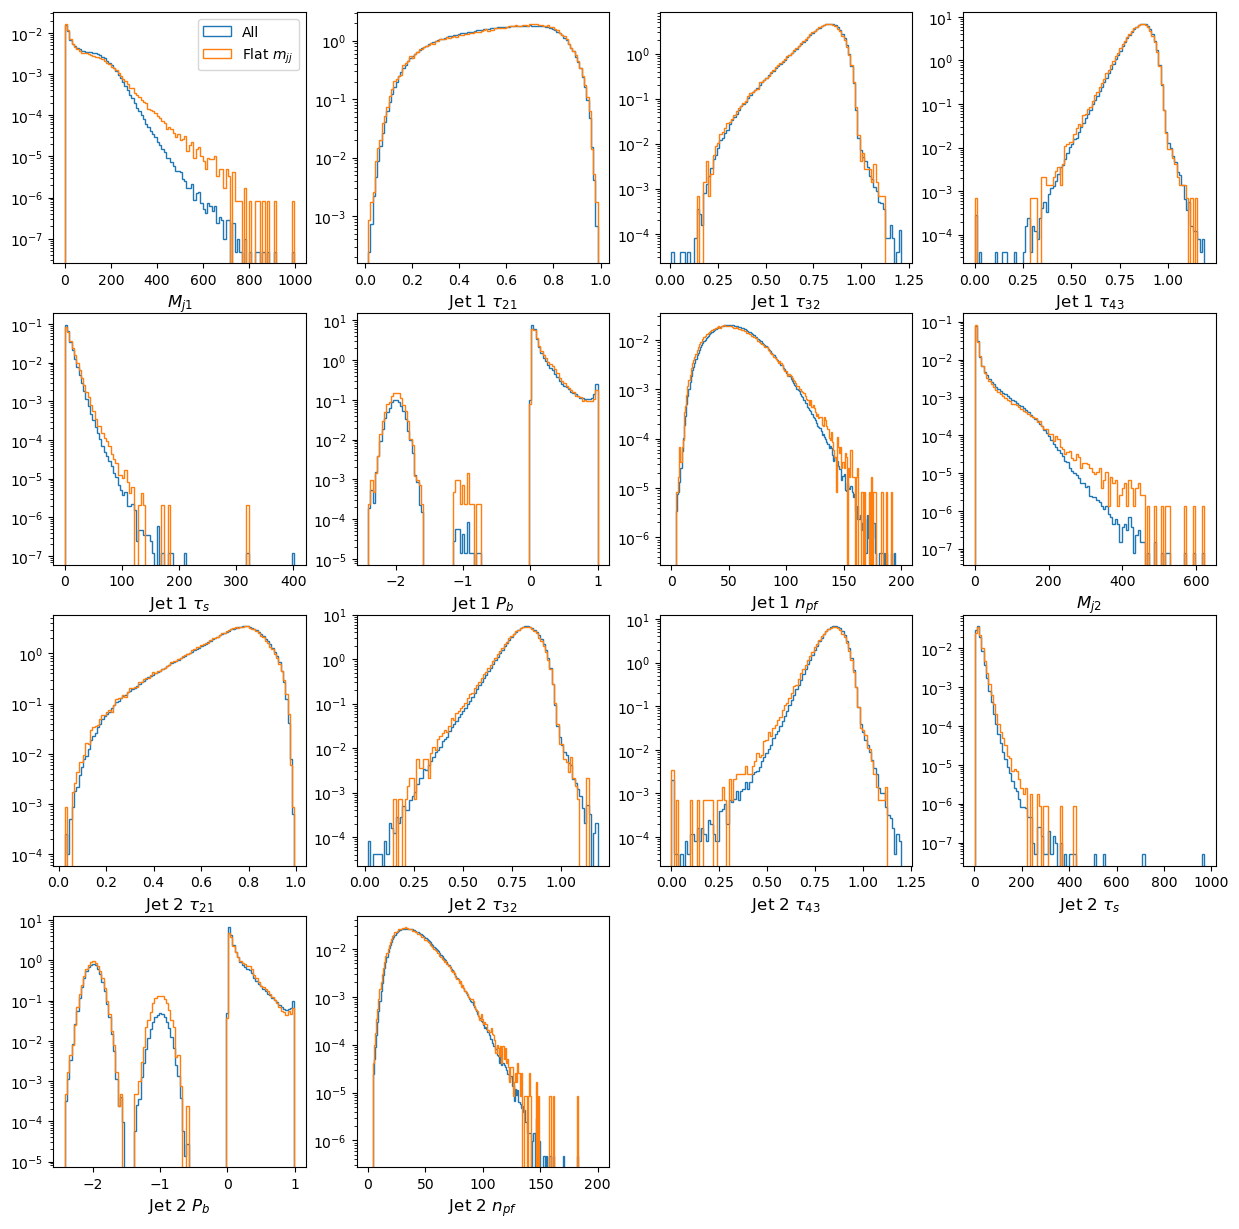

In [5]:
plt.figure(figsize=(15,15))
for i in range(len(names)):
    plt.subplot(4,4,i+1)
    name = names[i]
    if 'pf' in name:
        bins = np.arange(201)
    else:
        bins = 100
    n1,b1,p1 = plt.hist(train[:,i],bins=bins,density=True,histtype='step',label='All')
    h2 = plt.hist(totalSample[:,i],bins=b1,density=True,histtype='step',label=r'Flat $m_{jj}$')
    plt.xlabel(name,fontsize=12)
    plt.yscale('log')
    if i==0:
        plt.legend(loc='best')
plt.savefig('plots/misc/inputs_mjjFlat_vs_all.pdf')

# Train background model

In [6]:
print("Sample size: ",len(totalSample))

Sample size:  119106


Initial: 119106 events 
Final: 119086 events 
Removed 0.0168%
Device = cuda:0
FCNN Hidden Layer Width:  120
------------------------------------
Adjusting learning rate of group 0 to 1.0000e-03.
Loss:  21.9442
Adjusting learning rate of group 0 to 9.9976e-04.
Loss:  17.185385
Adjusting learning rate of group 0 to 9.9902e-04.
Loss:  14.648958
Adjusting learning rate of group 0 to 9.9780e-04.
Loss:  13.530915
Adjusting learning rate of group 0 to 9.9610e-04.
Loss:  13.593371
Adjusting learning rate of group 0 to 9.9391e-04.
Loss:  12.711443
Adjusting learning rate of group 0 to 9.9123e-04.
Loss:  12.326932
Adjusting learning rate of group 0 to 9.8808e-04.
Loss:  12.645616
Adjusting learning rate of group 0 to 9.8445e-04.
Loss:  12.073826
Adjusting learning rate of group 0 to 9.8035e-04.
Loss:  11.68024
Adjusting learning rate of group 0 to 9.7577e-04.
Loss:  11.6191
Adjusting learning rate of group 0 to 9.7074e-04.
Loss:  11.332769
Adjusting learning rate of group 0 to 9.6524e-04.
Loss: 

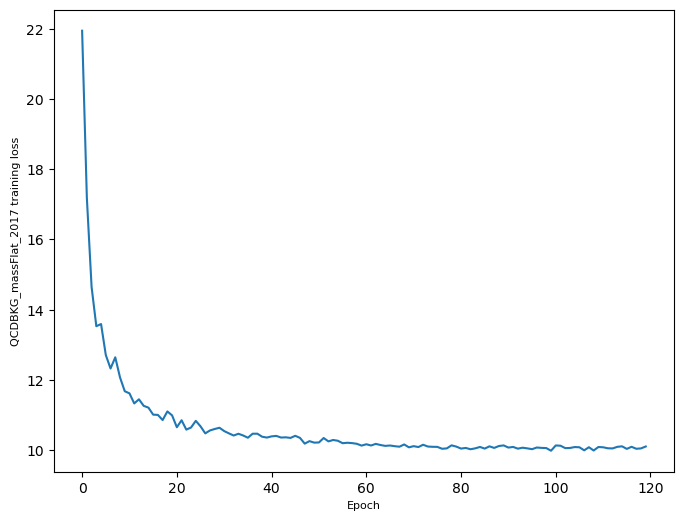

In [7]:
train_params = {"flow_type":"NSRATQUAD","tail_bound":15,"hidden_features":120,
                "num_layers":6,"num_bins":40,"num_blocks_per_layer":4,
                "clip":15,"patience":20,"learning_rate":1e-3,"save_model":True,"bs":10000,"nmax":100000}
with h5py.File("bkgMeanStds/QCDBKG_{0}.h5".format(year),"r") as f:
    mean = f["mean"][()]
    std = f["std"][()]

norm = np.copy(totalSample)
norm = hf.normalize_data(norm,inp_mean=mean,inp_std=std)

flow,flowName = hf.train_pipeline("QCDBKG_massFlat_{0}".format(year),norm,names,train_params,pt_cut=300,Mjj_cut=800)
del flow

# Evaluate Density Estimation

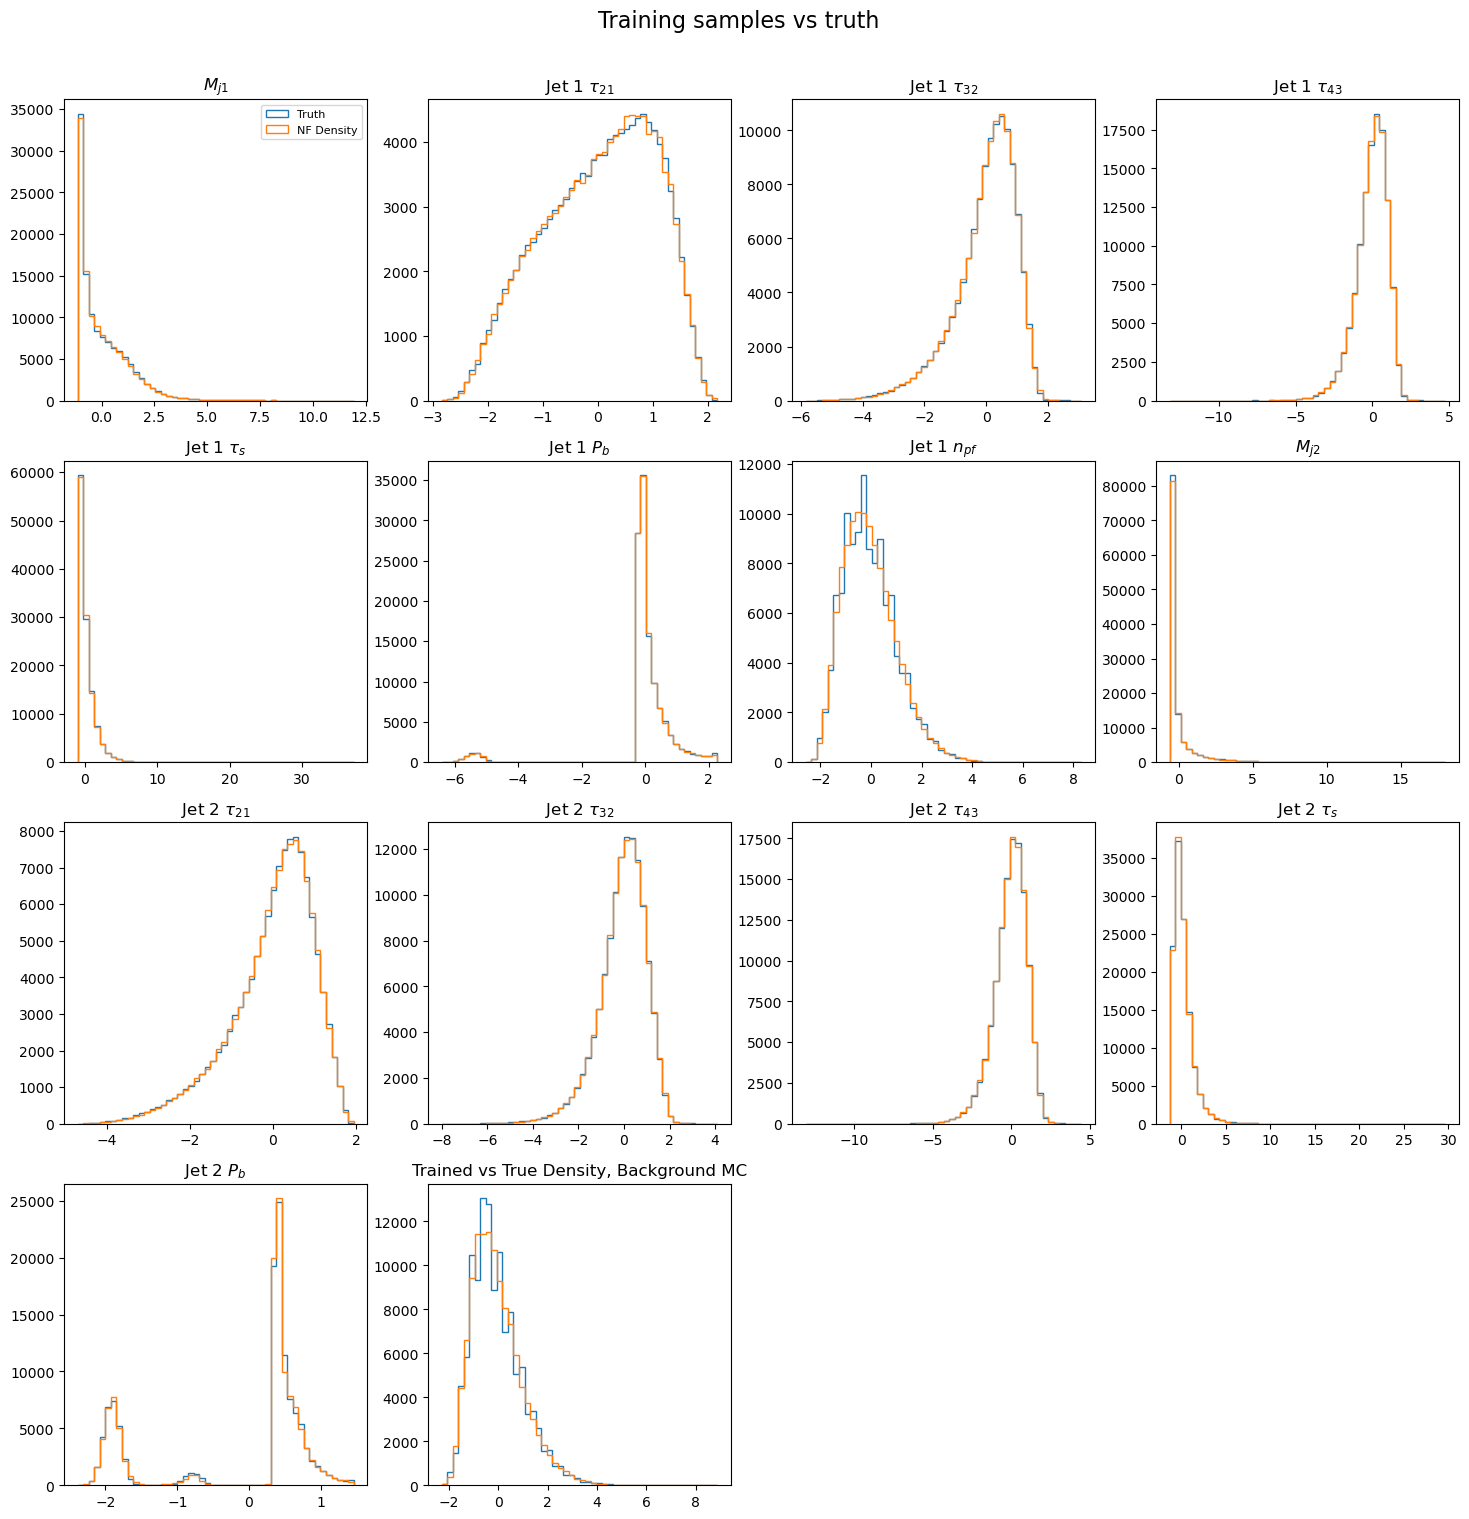

In [9]:
year=2017
with h5py.File("bkgMeanStds/QCDBKG_{0}.h5".format(year),"r") as f:
    mean = f["mean"][()]
    std = f["std"][()]

test = np.copy(totalSample)
test = hf.normalize_data(test,inp_mean=mean,inp_std=std)

flow = hf.load_model(name=flowName)
hf.plot_density_estimation(flow,test,names,log=False)
plt.title("Trained vs True Density, Background MC")
plt.savefig("plots/training_plots/"+flowName.split(".")[0]+"/density_estimation.pdf")